## Importing relevant libraries

In [6]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

from shapely import Point
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils.core.north_arrow import NorthArrow, north_arrow
from matplotlib_map_utils.core.inset_map import inset_map, indicate_extent, indicate_detail
from matplotlib_map_utils import set_size

import mpltern
import ternary 

from sklearn.decomposition import PCA
from sklearn import preprocessing 

import rasterio
from rasterio.plot import show

## Setting graph parameters

In [7]:
%matplotlib inline
plt.rcParams['font.sans-serif'] = 'Arial' # Choose a nice font here
plt.rcParams['font.size'] = 7 # standard font size
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['figure.facecolor'] = 'white' # make sure background isn't transparent
plt.rcParams['figure.dpi'] = 300

# Code for geological map 

## Loading data

In [10]:
#internet connection required to read urls 
#map of Mount Isa structural domains
#map layer 'Mount Isa Province - (GSQ)' from Geoscience Australia
#https://portal.ga.gov.au/
url1 = ("https://spatial-gis.information.qld.gov.au/arcgis/rest/services/GeoscientificInformation/StructuralFramework/MapServer/103/query?"
    "where=1%3D1&outFields=*&f=geojson")
mt_isa_data = gpd.read_file(url1) #map of structural segments of the Mount Isa Inlier 


#outline of Australian States
#map layer 'State and Territory (STE) - 2011 - (ABS)' from Geoscience Australia
#https://portal.ga.gov.au/
url2 = ("https://geo.abs.gov.au/arcgis/rest/services/ASGS2021/STE/MapServer/0/query?where=1%3D1&outFields=*&f=geojson")
AUS_borders= gpd.read_file(url2) #National borders


#location of the Elaine Dorothy Prospect
y=[-20.801110370354667]
x=[140.02237227360538]
elaine_dorothy = gpd.GeoSeries([Point(x, y)], crs=4326)

In [11]:
#loading topography geotiff
#original 3 second SRTM Derived Digital Elevation Model (DEM) Version 1.0 from Geoscience Australia
#https://ecat.ga.gov.au/geonetwork/srv/eng/catalog.search#/metadata/69888
#reduced size geotiff with hillshade (cropped in QGIS) is made available in github repository

with rasterio.open("mt_isa_hilshade.tif") as src:
    hillshade_img = src.read(1) # Read the first band
    hs_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

## Cropping data to sites of interest

In [12]:
#creating an outline of the Mount Isa Inlier
mt_isa_simplified= mt_isa_data.union_all() #removing structural distinctions in Mount Isa outline
mt_isa_complete= gpd.GeoSeries(mt_isa_simplified, crs=mt_isa_data.crs) # creating a GeoSeries
mt_isa_outline = gpd.GeoDataFrame(geometry=mt_isa_complete) # reading unified map as a data series 

In [13]:
#selecting the Queensland border from all states and territories
QLD=(AUS_borders.iloc[[2]]) 
#removing small islands for a clearer map
qld_parts = QLD.explode(index_parts=True)
qld_mainland = qld_parts.loc[[qld_parts.to_crs(epsg=3112).area.idxmax()]]
qld_plot=qld_mainland.to_crs(crs=mt_isa_data.crs)

In [14]:
#separating structural domains for the legend
Western_subprovince=mt_isa_data.iloc[[0]]
Eastern_fold_belt=mt_isa_data.iloc[[1]] 
Yaringa_subprovince=mt_isa_data.iloc[[2]] 
Kalkadoon_Leichhardt=mt_isa_data.iloc[[3]] 

## Creating map

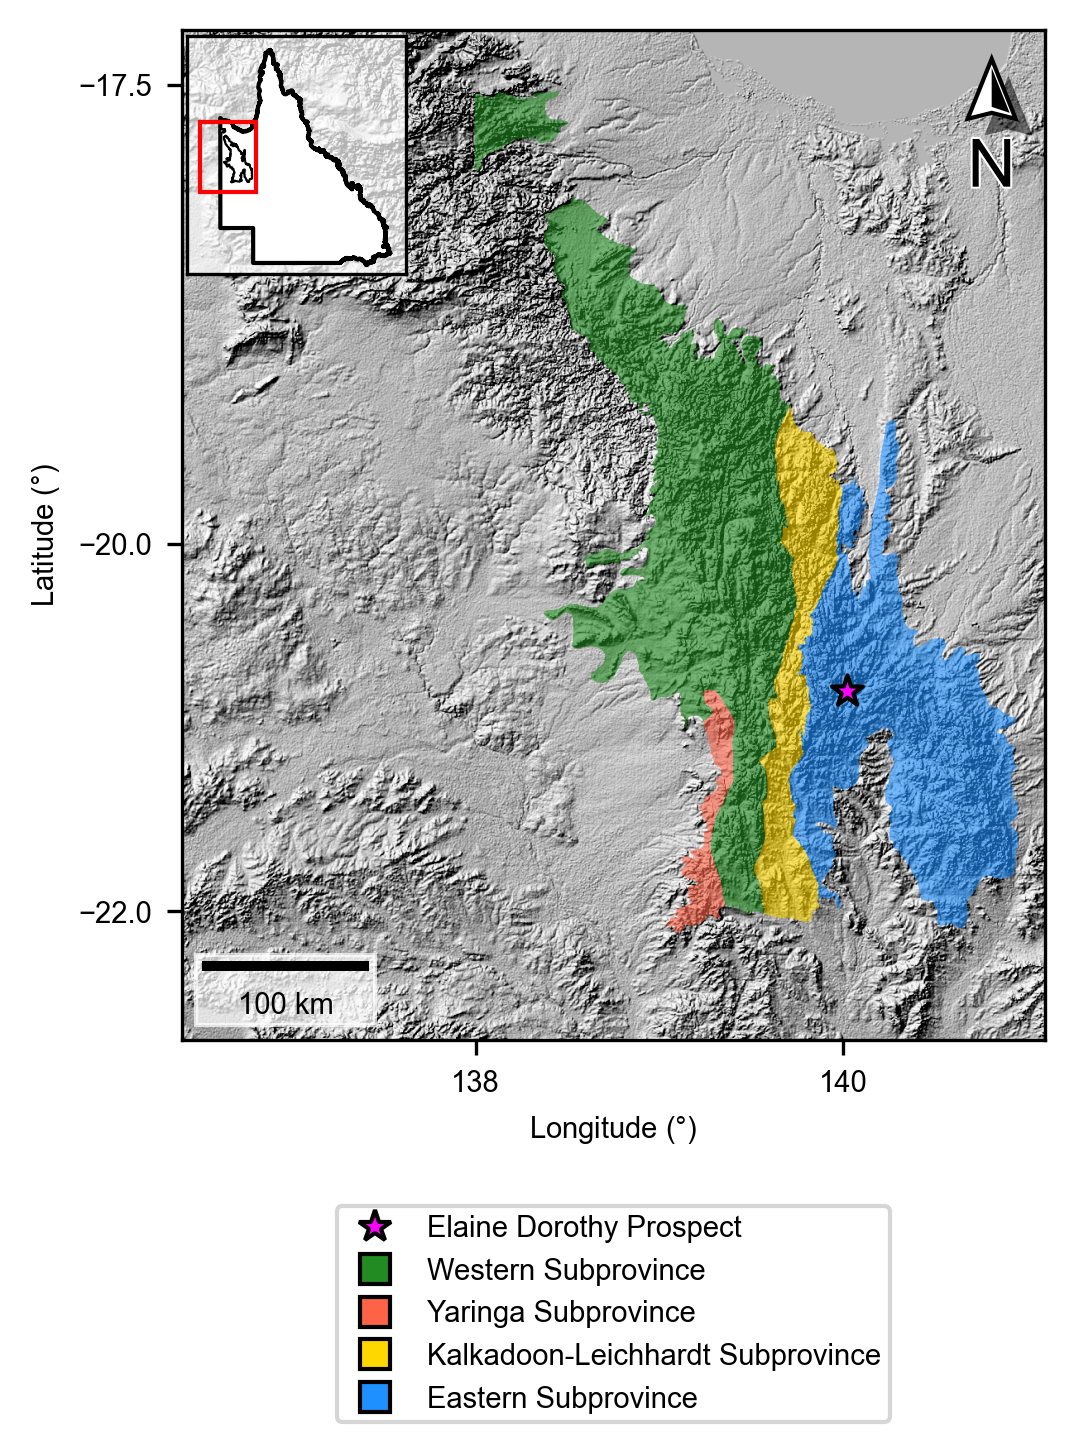

In [15]:
#plotting mines and deposits with inset of regional map
#may take a moment for map to load

Draft=False

#setting figure size
fig, ax = plt.subplots(figsize=(89/25.4, 120/25.4), layout='constrained')

#adding geotiff with scale as the map base 
ax.imshow(hillshade_img, cmap='gray', extent=hs_extent, origin='upper')

#information for the larger map
##structural domains
Western_subprovince.plot(ax=ax, color='forestgreen',alpha=0.6)
Eastern_fold_belt.plot(ax=ax, color='dodgerblue',alpha=0.6)
Kalkadoon_Leichhardt.plot(ax=ax, color='gold',alpha=0.6)
Yaringa_subprovince.plot(ax=ax, color='tomato',alpha=0.6)
##Field site
elaine_dorothy.plot(ax=ax, color='fuchsia', marker="*", markersize=60, edgecolor='k', zorder=5)


#adding the scale bar
points = gpd.GeoSeries([Point(140, -22.5), Point(140, -21.5)], crs=4326)
points_m = points.to_crs(3112)  # Projected into meters
distance_meters = points_m.iloc[0].distance(points_m.iloc[1])
ax.add_artist(ScaleBar(distance_meters, location = "lower left", pad=0.2, border_pad=0.5, box_alpha=0.7))
ax.set_aspect('equal')

#adding north arrow
north_arrow(ax, location="upper right", rotation={"crs":3112, "reference":"center"}, scale = 0.2)

#defining axes limits
ax.set_xlim(136.4, 141.1)
ax.set_ylim(-22.7, -17.2)

#labelling the axes
ax.set_xlabel('Longitude ($\\degree$)', fontsize=7)
ax.set_ylabel('Latitude ($\\degree$)', fontsize=7)

#setting tick marks
lat_ticks=[-22, -20, -17.5]
lon_ticks=[138, 140]
ax.set_yticks(lat_ticks)
ax.set_xticks(lon_ticks)

#adding a legend
legend_term_colour=[]

Elaine = Line2D([0],[0], marker='*', color='none', markerfacecolor = 'fuchsia', markersize=8, label='Elaine Dorothy Prospect', mec='k')
legend_term_colour.append(Elaine)

Western = Line2D([0],[0], marker='s', color='none', markerfacecolor = 'forestgreen', markersize=7, label='Western Subprovince', mec='k')
legend_term_colour.append(Western)

Yaringa = Line2D([0],[0], marker='s', color='none', markerfacecolor = 'tomato', markersize=7, label='Yaringa Subprovince', mec='k')
legend_term_colour.append(Yaringa)

Kalkadoon = Line2D([0],[0], marker='s', color='none', markerfacecolor = 'gold', markersize=7, label='Kalkadoon-Leichhardt Subprovince', mec='k')
legend_term_colour.append(Kalkadoon)

Eastern = Line2D([0],[0], marker='s', color='none', markerfacecolor = 'dodgerblue', markersize=7, label='Eastern Subprovince', mec='k')
legend_term_colour.append(Eastern)

plt.legend(handles=legend_term_colour, borderpad=0.3, fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.15))

#adding inset map
iax = inset_map(ax, location="upper left", xticks=[], yticks=[], size=0.8, pad=0.02)
mt_isa_outline.plot(ax=iax,color="white",edgecolor='k',zorder=5, linewidth=0.5)
qld_plot.plot(ax=iax,edgecolor='k',color='white')
iax.patch.set_alpha(0.7) #making background more transparent

#limits of inset axes
iax.set_xlim(135, 155) 
iax.set_ylim(-30, -9.5)

#adding a box to the inset to mark extent of larger map
indicate_extent(pax=iax, bax=ax, pcrs=4326, bcrs=4326, facecolor="none")


if Draft == False:
    plt.savefig("Map_abstract_final.pdf", bbox_inches='tight',dpi=300) 
    plt.savefig("Map_abstract_final.png", bbox_inches='tight',dpi=300)

# Shared code blocks for ternary diagram and PCA

## Loading major element data

In [9]:
#data for ternary diagram and PCA
#available in github repository
biotites=pd.read_csv('monash_biotite.csv')

## Assigning colours for each slide

In [10]:
#code for assigning slide colours

ED_colours = {'EDC01':'royalblue',
              'EDC29B':'firebrick',
              'EDC08':'darkcyan',
              'EDC017':'lightgreen',
              'EDC02':'hotpink',
              'EDC024':'sandybrown'}

def colours (data_set_samples):
    return ED_colours.get(data_set_samples, 'grey')

colours_assigned = biotites['Slide'].map(colours)

# Code for ternary diagram

## Data for interest

In [11]:
#select relevant data for ternary diagram 
#note for this composition, Fe3+ was not recalculated
Mg = biotites['Mg_M']
Ti = biotites['Ti_M']
Fe2 = biotites['Fe_M']
Mn = biotites['Mn_M']
AlVI= biotites['Al_M']
Slide=biotites["Slide"]

## Constructing ternary diagram

In [12]:
#defining corners for the ternary diagram
top = Mg
left = AlVI + Ti #add Fe3 if measured
right = Fe2 + Mn

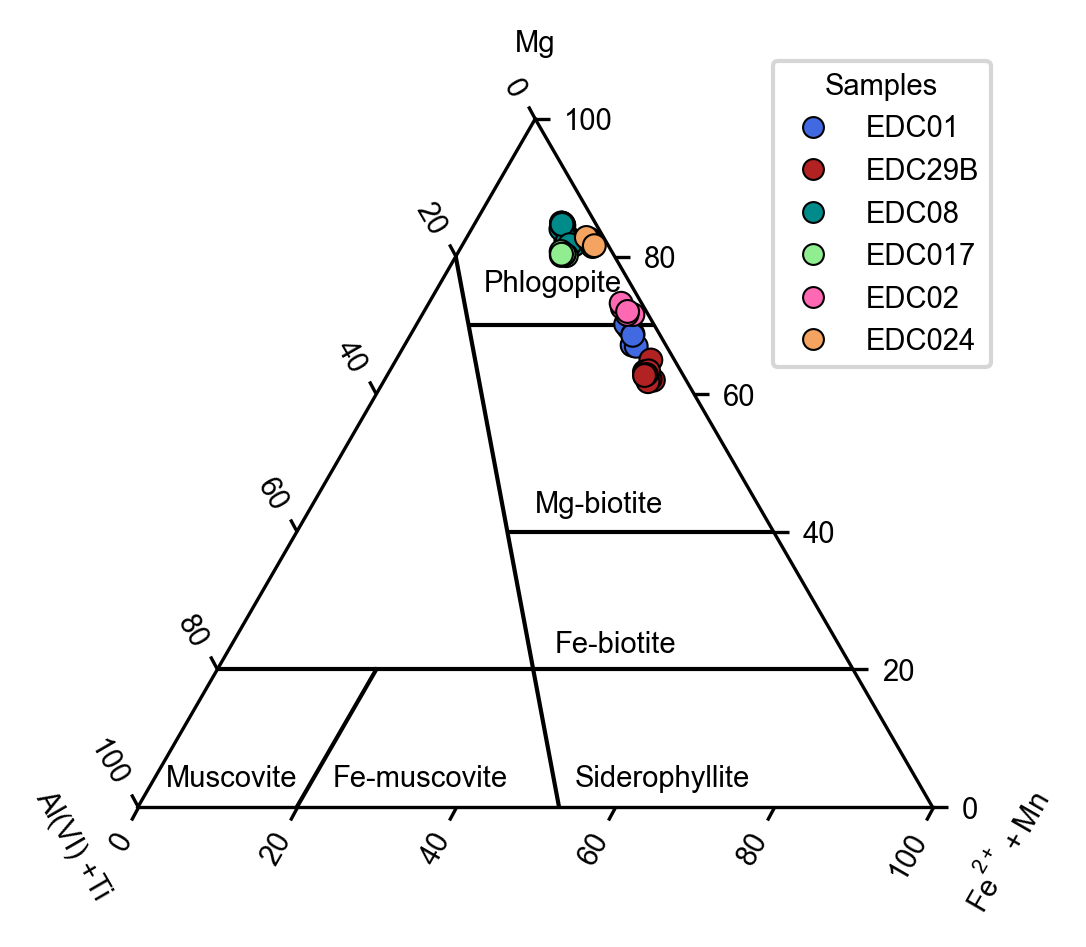

In [13]:
#Values based on paper by Sepidbar et al. (2017) and references therein 
#DOI:10.1016/j.oregeorev.2017.08.029

Draft2 = False

#set figure size
fig = plt.figure(figsize=(89/25.4, 89/25.4), layout='constrained')

#plotting points
ax = fig.add_subplot(projection="ternary", ternary_sum=100)
ax.scatter(top, left, right, s=30, c=colours_assigned, edgecolors='k', linewidth=0.5, zorder=3)

#adding vertices labels 
ax.set_tlabel("Mg", fontsize=7)
ax.set_llabel("Al(VI) +Ti", fontsize=7)
ax.set_rlabel(r"$Fe^{2+} + Mn$", fontsize=7)

#add in compositional boundaries based on Sepidbar et al. (2017)
t1,l1,r1 = [0, 80], [47, 20],[53, 0]
ax.plot(t1, l1, r1, color='k', linewidth=1)

t2,l2,r2 = [20, 20],[0, 80],[80, 0]
ax.plot(t2, l2, r2, color='k', linewidth=1, zorder=2)

t3,l3,r3 = [70, 70],[0, 23],[30, 7]
ax.plot(t3, l3, r3, color='k', linewidth=1, zorder=2)

t4,l4,r4 = [40, 40],[33.3, 0],[26.7, 60]
ax.plot(t4, l4, r4, color='k', linewidth=1, zorder=2)

t5,l5,r5 = [0, 20],[80, 60],[20, 20]
ax.plot(t5, l5, r5, color='k', linewidth=1, zorder=2)

#labelling compositional zones
ax.text(75,19,6,'Phlogopite',fontsize=7)
ax.text(45,30,30,'Mg-biotite',fontsize=7)
ax.text(23,37,42,'Fe-biotite',fontsize=7)
ax.text(3,44,54,'Siderophyllite',fontsize=7)
ax.text(3,74,23,'Fe-muscovite',fontsize=7)
ax.text(3,95,2,'Muscovite',fontsize=7)

#addiing legend
colours2=pd.unique(colours_assigned)
samples=pd.unique(Slide)
legend_elements=[]
for x, y in zip(samples, colours2):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=x, markerfacecolor=y, markersize=5, markeredgecolor='k', markeredgewidth=0.5))
plt.legend(handles=legend_elements, loc='upper right', borderaxespad=-2, title="Samples", fontsize=7)

#saving figure
if Draft2 == False:
    plt.savefig("Foster_abstract_ternary.pdf")
    plt.savefig("Foster_abstract_ternary.png")

# Code for PCA

## Creating dataframe

In [14]:
#creating pandas data frame for PCA
elements_of_df = ["Slide","   SiO2  ","   MgO   ","   CaO   ","   Al2O3 ","   F     ","   FeO   ","   MnO   ","   TiO2  ","   Cl    ","   Na2O  ","   K2O   "]
biotites_wts = pd. DataFrame(biotites[elements_of_df])
biotites_wts_df=biotites_wts.set_index("Slide")

## Calculations for PCA

In [15]:
#scaling data 
biotites_scaled_data = preprocessing.scale(biotites_wts_df) 

In [16]:
#determining principal components
pca = PCA()
pca_data = pca.fit(biotites_scaled_data) #calculating loading scores and variation 
per_var=np.round(pca.explained_variance_ratio_*100, decimals=1) #percentage of variation for scree plot
pca_data_biotites = pca.transform(biotites_scaled_data) #creating coordinates for PCA graph

In [17]:
#saving PCA coordinates as a data frame for graphing 
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]
pca_df = pd.DataFrame(pca_data_biotites, index=biotites["Slide"], columns=labels)

## Graph of PC1 and PC2 with inset scree plot

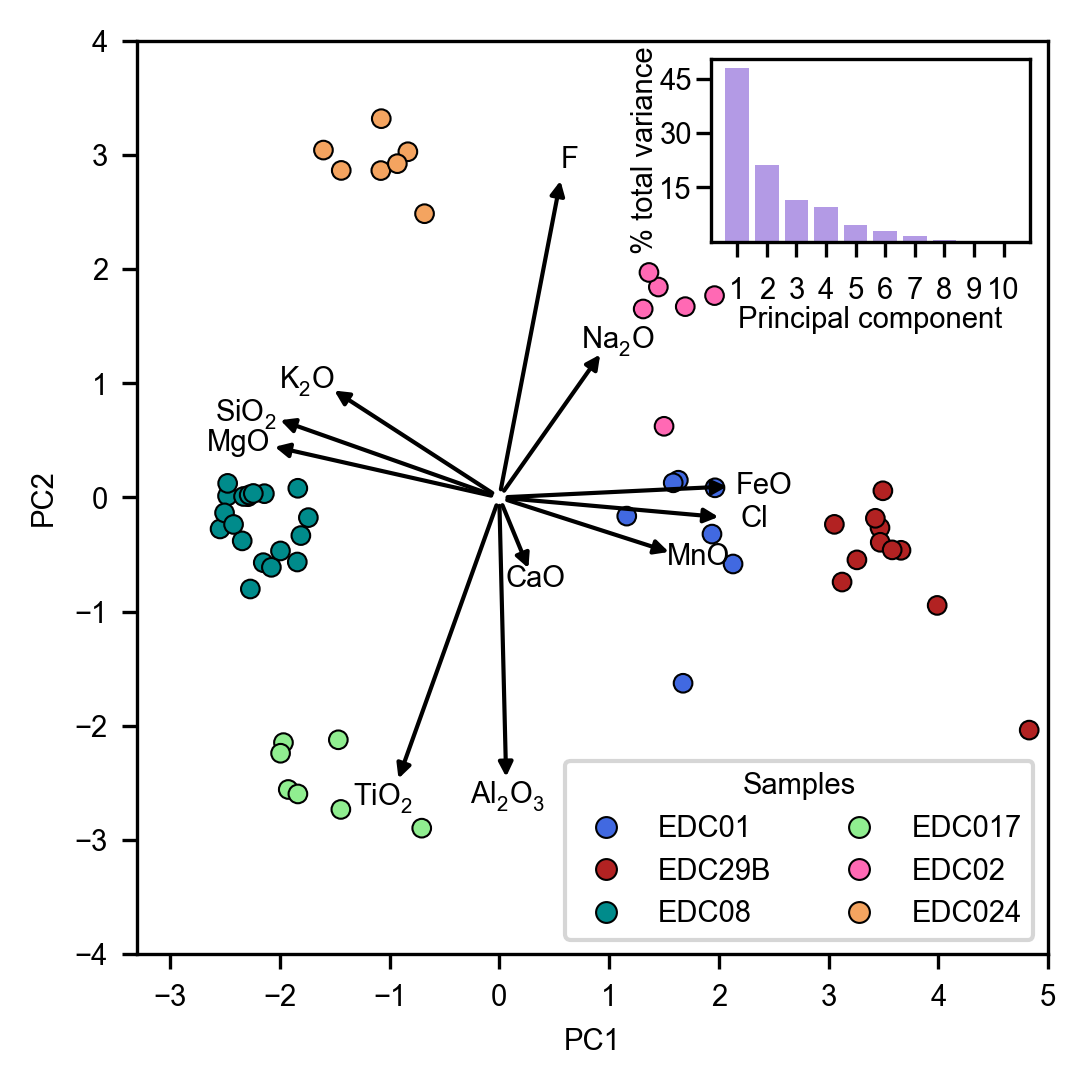

In [18]:
#with vectors

Draft3=False

#setting size
fig, ax = plt.subplots(figsize=(89/25.4, 89/25.4), layout='constrained')

#PCA graph
ax.scatter(pca_df['PC1'],pca_df['PC2'], c=colours_assigned, edgecolor='k', s=20, linewidths=0.5)

#labelling axes
ax.set_xlabel('PC1'.format(per_var[0]), labelpad=4)
ax.set_ylabel('PC2'.format(per_var[1]), labelpad=4)

#setting axes limits
ax.set_xlim(-3.3, 5)
ax.set_ylim(-4, 4)

#adding legend
legend_slides=pd.unique(biotites['Slide'])
legend_colours=pd.unique(colours_assigned)
legend_elements=[]
for x, y in zip(legend_slides, legend_colours):
    legend_elements.append(Line2D([0], [0], marker='o', color='w', label=x, markerfacecolor=y, markersize=5, markeredgecolor='k', markeredgewidth=0.5))
plt.legend(handles=legend_elements, loc='lower right', ncol=2, title="Samples",fontsize=7)

#adding eigen vectors
column_names = (elements_of_df[1:]) #retrieving names of variables
#formatting variable names 
display_names=['SiO$_2$','MgO','CaO','Al$_2$O$_3$','F','FeO','MnO','TiO$_2$','Cl','Na$_2$O','K$_2$O']
#adding vectors as arrows with formatted variable names
loadings = pd.DataFrame(pca_data.components_.T[:, :2], columns=['PC1', 'PC2'], index=column_names)
scale = 5
for i, oxide in enumerate(display_names):
    lx = loadings.iloc[i, 0] * scale
    ly= loadings.iloc[i, 1] * scale
    plt.annotate("",xy=(lx,ly),xytext=(0,0),
                arrowprops = dict(arrowstyle = "-|>", color="k",lw=1))
    plt.text(lx*1.12, ly*1.04, oxide, color="k", fontsize=7, ha="center", va="center")

#adding an inset scree plot

#axes proportions
axin2 = ax.inset_axes([0.63, 0.78, 0.35, 0.20])

#data to be graphed 
## PCA11 is removed for graphical simplicity as it does not show a significant percentage
axin2.bar(x=range(1,len(per_var)), height=per_var[:10], tick_label=labels[:10], color='mediumpurple', alpha=0.7)

#adding axis labels 
axin2.set_ylabel('% total variance', fontsize=7,labelpad=0.1)
axin2.set_xlabel('Principal component',fontsize=7,labelpad=0.1)

#adding labelled tick marks
yticks=[15,30,45]
index_num=np.arange(1, len(per_var))
axin2.set_xticklabels(index_num)
axin2.set_yticks(yticks)
axin2.tick_params(axis='both', which='major', labelsize=7,pad=5)
plt.setp(axin2.get_xticklabels(), rotation=0, ha="center",fontsize=7)
plt.setp(axin2.get_yticklabels(), rotation=0, ha="center",fontsize=7)


#saving figure
if Draft3 == False:
    plt.savefig("PCA_abstract_w_inset.pdf" )
    plt.savefig("PCA_abstract_w_inset.png")